# Multimodal Search — Query Examples

Interactive queries against the multimodal index built by this kit. The index is *multimodal*: every page produces **text rows** (`kind=text`, 3072-dim text vectors) and extracted **image rows** (`kind=image`, 1024-dim Vision vectors).

This notebook defaults to the **delegated** index (`sharepoint-page-index-del`), which has **no ACL trimming**. To query the application-permission index (`sharepoint-page-index`, security-trimmed by SharePoint ACLs), change `INDEX_NAME` in the setup cell.

The examples below show:

1. **Hybrid text search** — BM25 + text vectors + semantic reranking
2. **Text → image (cross-modal)** — a *text* query retrieves matching *images* via the Vision vectorizer
3. **Semantic Q&A** — natural-language question over the text
4. **Filtered search** — scope by `kind` / page range with an OData filter
5. **Combined multimodal** — one query returns both text and image hits

> Auth uses `DefaultAzureCredential` (run `az login` first) and needs **Search Index Data Reader**. For the **application-permission** index the helper also sends `x-ms-query-source-authorization`, so results are security-trimmed to what you can see in SharePoint; the delegated index has no such trimming.


## Setup

Install dependencies (once), then load config from `.env` / `.env.derived` and define the query helpers.

In [1]:
%pip install -q azure-identity requests

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import os, base64, html, re, textwrap
from pathlib import Path

import requests
from azure.identity import DefaultAzureCredential
from IPython.display import display, HTML, Image


def _find_root(start: Path) -> Path:
    """Walk up from the notebook's directory to find the folder holding .env."""
    for p in [start, *start.parents]:
        if (p / ".env").exists():
            return p
    return start


def _load_env(path: Path) -> None:
    if not path.exists():
        return
    for raw in path.read_text(encoding="utf-8").splitlines():
        line = raw.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, val = line.split("=", 1)
        key, val = key.strip(), val.lstrip()
        if val[:1] in ('"', "'"):
            q = val[0]
            end = val.find(q, 1)
            val = val[1:end] if end >= 1 else val[1:]
        else:
            h = val.find("#")
            val = (val[:h] if h >= 0 else val).strip()
        os.environ[key] = val


ROOT = _find_root(Path.cwd())
_load_env(ROOT / ".env")            # base config
_load_env(ROOT / ".env.derived")    # provisioning outputs (SEARCH_ENDPOINT, ...)

SEARCH_ENDPOINT = os.environ["SEARCH_ENDPOINT"].rstrip("/")
# Primary index for this notebook is the DELEGATED index (no ACL trimming).
# Change to "sharepoint-page-index" to query the application-permission (ACL) index.
INDEX_NAME = "sharepoint-page-index-del"
API_VERSION = os.environ.get("SEARCH_API_VERSION", "2026-05-01-preview")

_cred = DefaultAzureCredential()


def _token() -> str:
    return _cred.get_token("https://search.azure.com/.default").token


display(HTML(
    "<div style='font-family:Segoe UI,system-ui,sans-serif;font-size:13px;"
    "border:1px solid #d3e2ff;background:#eef4ff;border-radius:8px;padding:10px 14px'>"
    f"<b>Connected</b> &nbsp;·&nbsp; index <code>{html.escape(INDEX_NAME)}</code> "
    f"@ <code>{html.escape(SEARCH_ENDPOINT)}</code></div>"
))


In [25]:
def search(query, top=5, filter=None, text_vector=True, image_vector=False,
           semantic=True, select="id,kind,sourceFile,page,pageTo,webUrl,content"):
    """Run a query against the index.

    text_vector  -> add a vector query over contentVector (OpenAI text embeddings)
    image_vector -> add a vector query over imageVector  (Vision; text is embedded
                    into image space, enabling cross-modal text->image search)
    """
    token = _token()
    url = f"{SEARCH_ENDPOINT}/indexes/{INDEX_NAME}/docs/search?api-version={API_VERSION}"
    headers = {
        "Content-Type": "application/json",
        "Authorization": f"Bearer {token}",
    }
    # Only send the ACL-trimming token to indexes that have permission filtering
    # enabled. Indexes without it (e.g. the delegated "-del" index) reject it (400).
    if not INDEX_NAME.endswith("-del"):
        headers["x-ms-query-source-authorization"] = token
    payload = {"search": query, "top": top, "select": select}
    if filter:
        payload["filter"] = filter
    vq = []
    if text_vector:
        vq.append({"kind": "text", "text": query, "fields": "contentVector", "k": top})
    if image_vector:
        vq.append({"kind": "text", "text": query, "fields": "imageVector", "k": top})
    if vq:
        payload["vectorQueries"] = vq
    if semantic:
        payload["queryType"] = "semantic"
        payload["semanticConfiguration"] = "default"
    r = requests.post(url, headers=headers, json=payload, timeout=60)
    r.raise_for_status()
    return r.json().get("value", [])


# ---- presentation helpers (clean HTML cards) -------------------------------

_STYLE = """
<style>
.qx { font-family: 'Segoe UI', system-ui, -apple-system, sans-serif; }
.qx-card { border:1px solid #e6e6e6; border-radius:10px; padding:12px 16px;
           margin:10px 0; background:#fff; box-shadow:0 1px 2px rgba(0,0,0,.05); }
.qx-head { display:flex; align-items:center; gap:8px; flex-wrap:wrap; margin-bottom:6px; }
.qx-rank { display:inline-flex; align-items:center; justify-content:center; min-width:22px;
           height:22px; padding:0 7px; border-radius:11px; background:#0b6bcb; color:#fff;
           font-size:12px; font-weight:600; }
.qx-file { font-weight:600; color:#1f1f1f; }
.qx-meta { color:#777; font-size:12px; }
.qx-badge { margin-left:auto; background:#eef4ff; color:#0b6bcb; border:1px solid #d3e2ff;
            border-radius:6px; padding:2px 9px; font-size:11px; font-weight:600; white-space:nowrap; }
.qx-body { color:#333; font-size:13px; line-height:1.55; }
.qx-link { font-size:12px; margin-top:8px; display:inline-block; color:#0b6bcb; text-decoration:none; }
.qx-img { border:1px solid #eee; border-radius:8px; height:auto; margin-top:4px; }
.qx-empty { color:#999; font-style:italic; padding:10px 2px; }
.qx-sec { font-weight:700; font-size:14px; margin:16px 0 2px; color:#111;
          border-left:3px solid #0b6bcb; padding-left:8px; }
</style>
"""


def _clean(text):
    """Strip Content-Understanding page markers / figure tags / HTML for readable snippets."""
    if not text:
        return ""
    text = re.sub(r"<!--.*?-->", " ", text, flags=re.S)        # <!-- PageHeader ... -->
    text = re.sub(r"!\[[^\]]*\]\([^)]*\)", " ", text)          # ![](figures/..)
    text = re.sub(r"<[^>]*>", " ", text)                        # HTML tags (tables etc.)
    text = re.sub(r"[#*`]+", " ", text)                         # md heading/emphasis marks
    return re.sub(r"\s+", " ", text).strip()


def _trim(text, n=360):
    return text if len(text) <= n else text[:n].rstrip() + "\u2026"


def _score(h):
    rr, sc = h.get("@search.rerankerScore"), h.get("@search.score")
    return f"reranker {rr:.2f}" if rr is not None else f"score {sc:.2f}"


def show_text(hits):
    if not hits:
        display(HTML(_STYLE + "<div class='qx qx-empty'>No results \u2014 check you're "
                     "<code>az login</code>'d and have <b>Search Index Data Reader</b>.</div>"))
        return
    parts = [_STYLE, "<div class='qx'>"]
    for i, h in enumerate(hits, 1):
        body = html.escape(_trim(_clean(h.get("content"))))
        link = (f"<a class='qx-link' href='{html.escape(h['webUrl'])}'>Open in SharePoint \u2197</a>"
                if h.get("webUrl") else "")
        parts.append(
            "<div class='qx-card'><div class='qx-head'>"
            f"<span class='qx-rank'>{i}</span>"
            f"<span class='qx-file'>{html.escape(h.get('sourceFile','(unknown)'))}</span>"
            f"<span class='qx-meta'>page {h.get('page')}</span>"
            f"<span class='qx-badge'>{_score(h)}</span></div>"
            f"<div class='qx-body'>{body}</div>{link}</div>"
        )
    parts.append("</div>")
    display(HTML("".join(parts)))


def show_images(hits, width=300):
    if not hits:
        display(HTML(_STYLE + "<div class='qx qx-empty'>No image results.</div>"))
        return
    parts = [_STYLE, "<div class='qx'>"]
    for i, h in enumerate(hits, 1):
        name = (h.get("imagePath") or "").rsplit("/", 1)[-1]
        data = h.get("imageData")
        img = (f"<img class='qx-img' style='max-width:{width}px' "
               f"src='data:image/jpeg;base64,{data}'/>" if data else "")
        parts.append(
            "<div class='qx-card'><div class='qx-head'>"
            f"<span class='qx-rank'>{i}</span>"
            f"<span class='qx-file'>{html.escape(h.get('sourceFile','(unknown)'))}</span>"
            f"<span class='qx-meta'>page {h.get('page')} \u00b7 {html.escape(name)}</span>"
            f"<span class='qx-badge'>score {h.get('@search.score', 0):.2f}</span></div>"
            f"{img}</div>"
        )
    parts.append("</div>")
    display(HTML("".join(parts)))


def section(title):
    display(HTML(_STYLE + f"<div class='qx qx-sec'>{html.escape(title)}</div>"))


## 1. Hybrid text search

BM25 keyword matching **fused with** text-vector similarity, then re-ordered by the semantic ranker. The `kind eq 'text'` filter keeps results to text chunks.

In [26]:
hits = search("What is osteoporosis and why is it a health care burden?",
              top=5, filter="kind eq 'text'")
show_text(hits)

## 2. Text \u2192 image (cross-modal) search

A **text** query is embedded into the **image** vector space by the Vision vectorizer, so it retrieves matching figures/diagrams directly. We filter to `kind eq 'image'` and render the extracted images inline from the base64 stored in the index.


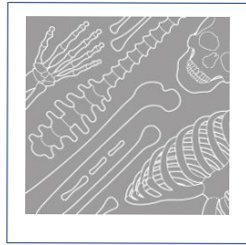
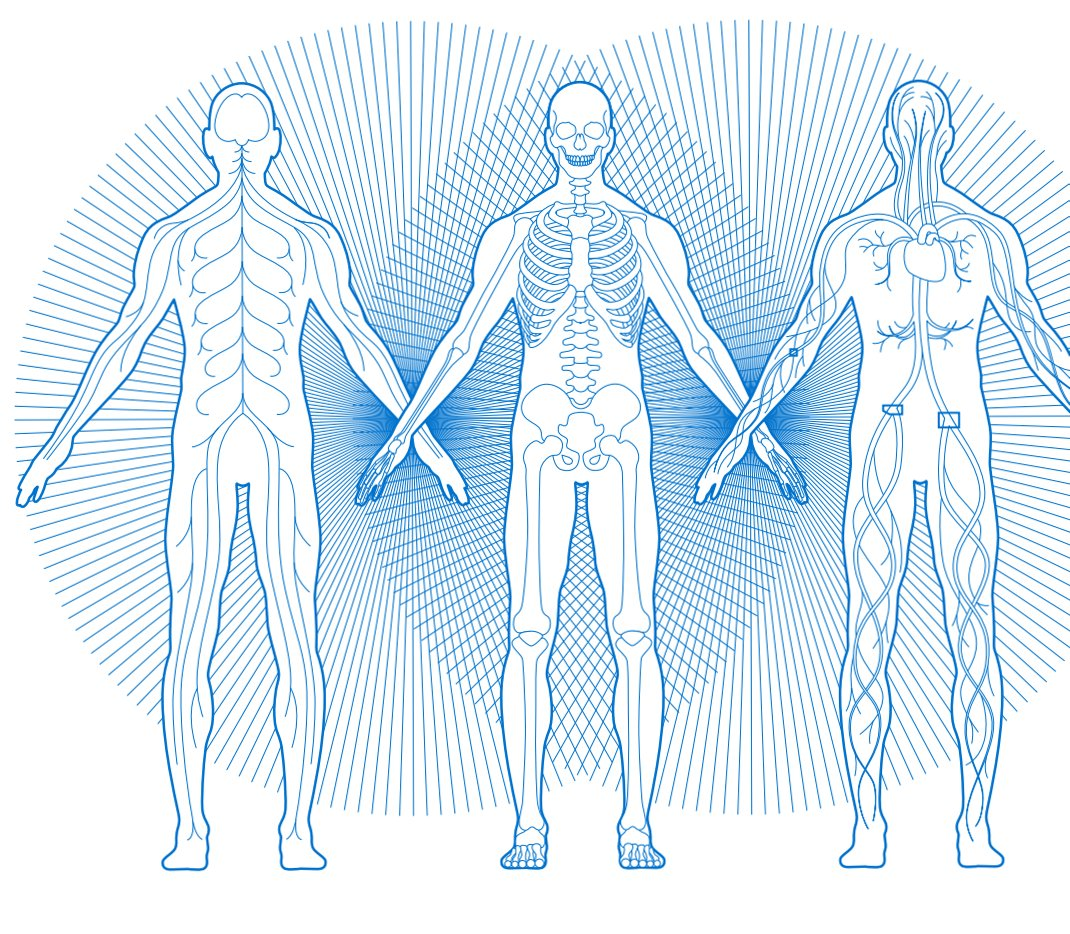
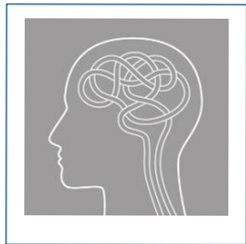
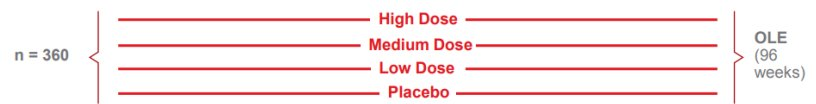

In [27]:
hits = search("illustration of the human skeleton and bones",
              top=4,
              filter="kind eq 'image'",
              text_vector=False, image_vector=True,
              semantic=False,
              select="id,kind,sourceFile,page,imagePath,imageData")
show_images(hits)

## 3. Semantic Q&A over the text

A natural-language question. Hybrid retrieval finds candidates and the semantic ranker surfaces the most answer-like passages (`@search.rerankerScore`).

In [28]:
hits = search("Which therapies or drug classes are used to treat bone diseases?",
              top=5, filter="kind eq 'text'")
show_text(hits)

## 4. Filtered search (OData `$filter`)

Combine vector/semantic relevance with structured filters — here, text rows within a page range. Filterable fields include `kind`, `page`, `pageTo`, `sourceFile`, and `lastModified`.

In [29]:
hits = search("fracture risk and bone mineral density",
              top=5,
              filter="kind eq 'text' and page ge 85 and page le 100")
show_text(hits)

## 5. Combined multimodal view

Answer the **same query across both modalities** — one retrieval over text passages and one cross-modal retrieval over images — then present them together. This is the typical RAG pattern: ground an answer on the top text *and* surface the most relevant figures.



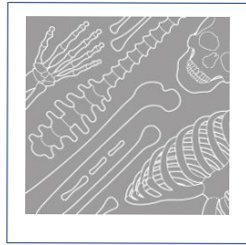
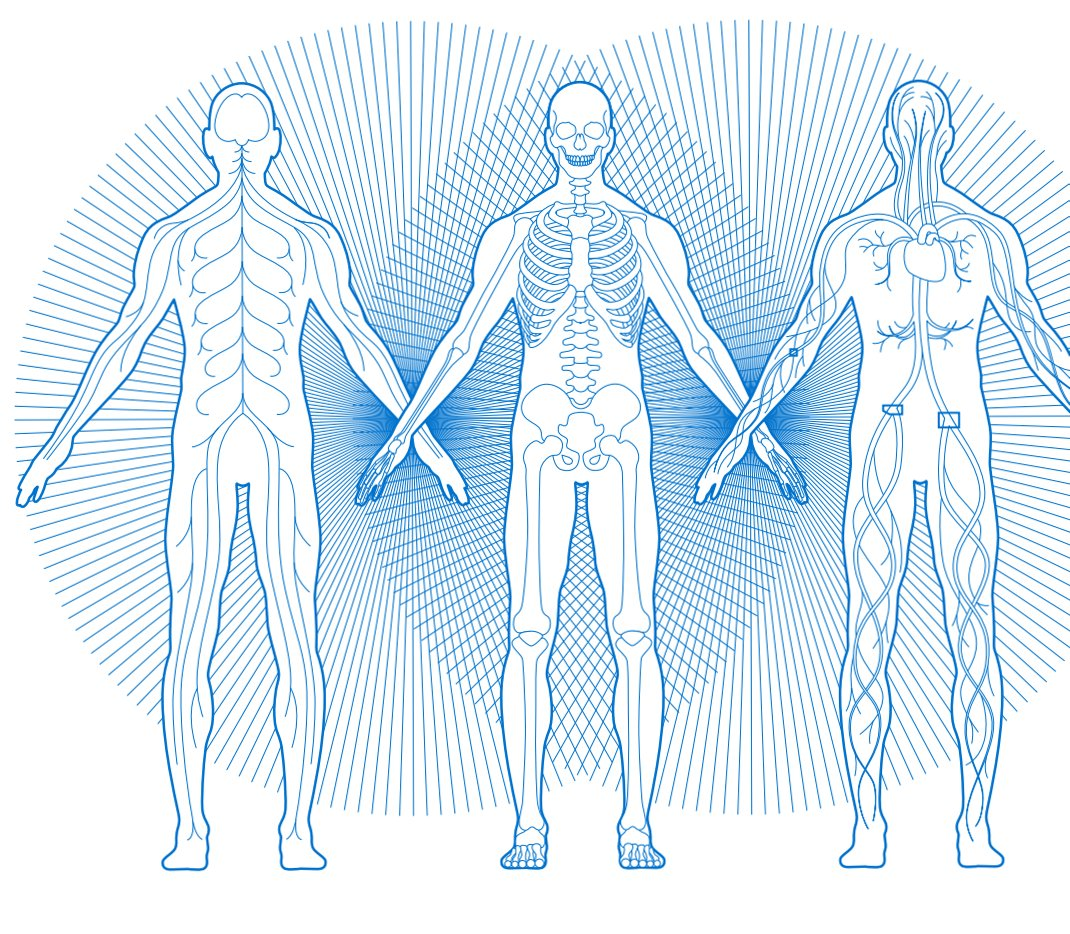
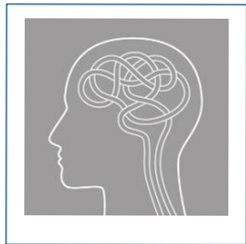
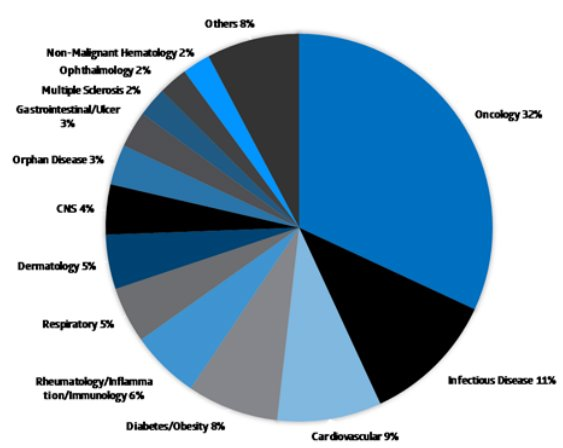

In [30]:
query = "skeletal system, bone structure and fractures"

# Top text passages (hybrid + semantic)
text_hits = search(query, top=4, filter="kind eq 'text'")

# Top matching images (cross-modal: text embedded into image space)
image_hits = search(query, top=4,
                    filter="kind eq 'image'",
                    text_vector=False, image_vector=True, semantic=False,
                    select="id,kind,sourceFile,page,imagePath,imageData")

section(f"Top text passages ({len(text_hits)})")
show_text(text_hits)
section(f"Top matching images ({len(image_hits)})")
show_images(image_hits)


---
### Notes

- **Index selection:** set `INDEX_NAME` in the setup cell — `sharepoint-page-index-del` (delegated, no trimming, the default) or `sharepoint-page-index` (application-permission, ACL-trimmed).
- **Security trimming (ACL index only):** on `sharepoint-page-index`, results are limited to documents whose `UserIds`/`GroupIds` match your identity; querying with an admin key or no user token returns **0** rows by design. The delegated index has no permission filtering, so the helper does not send the trimming header to it.
- **Edit the queries:** swap in your own phrasing above. Toggle `text_vector` / `image_vector`, adjust `filter`, or set `semantic=False` to see raw hybrid ranking.
- **Fields:** `contentVector` (3072) and `imageVector` (1024) are searchable but not retrievable; retrievable fields include `content`, `imagePath`, `imageData`, `page`, `sourceFile`, `webUrl`.
